In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

# 🔐 Connect to IBM Quantum using API token
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="SUEmF_-FaRRwvEv1wMqNL-tT922E-i8pUPLsvwxFhGtr"
)

# Choose REAL hardware
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=4
)

print("Using backend:", backend.name)

# Create sampler for execution
sampler = Sampler(backend)

qiskit_runtime_service._discover_account:WARNING:2026-04-01 16:26:55,101: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-01 16:27:02,030: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-01 16:27:02,690: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-01 16:27:08,137: Using instance: open-instance, plan: open


Using backend: ibm_fez


In [6]:
# Parameters

E=1
dm2 = 1
theta =0.195
sin_2th   = np.sin(2*theta)
cos_2th   = np.cos(2*theta)
omega = dm2/(4.0*E)

bx = omega * np.sin(2 * theta)
by = 0.0
bz = -omega * np.cos(2 * theta)

# number of nu #
N = 4

In [7]:
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J

In [10]:
def add_interaction_evolution_hw(qc, n, J, N, dt):
    """
    Hardware-friendly all-to-all Heisenberg evolution
    using a linear SWAP network.
    """

    for _ in range(n):

        # Track which logical qubit sits at each position
        order = list(range(N))

        for layer in range(N - 1):

            # --- Interact nearest neighbors ---
            for k in range(0, N - 1, 2):
                i = order[k]
                j = order[k + 1]

                phi = 2.0 * J[i, j] * dt

                qc.rxx(phi, k, k + 1)
                qc.ryy(phi, k, k + 1)
                qc.rzz(phi, k, k + 1)

            # --- Swap to move qubits along chain ---
            for k in range(1, N - 1, 2):
                qc.swap(k, k + 1)

                # Update logical ordering
                order[k], order[k + 1] = order[k + 1], order[k]

In [21]:
initial_bits = [0, 0, 1, 1]
# Interaction matrix
J = interaction_matrix(N, dm2, E)

# Initial state prepared outside
qc0 = QuantumCircuit(N, N)
qc0.x(2)# example: qubit 2 is nu_mu
qc0.x(3)# example: qubit 3 is nu_mu
P_inv = [[] for _ in range(N)]
dt=0.5
T_max = 40 
steps = int(T_max / (8*dt)) 
times_hw = np.linspace(4, T_max, steps)
shots = 4096

# --- 10 time points from dt=4 to dt=40 ---
#time_points = np.linspace(4, 40, 10, dtype=int)

circuits = []

# ---------- Build circuits ----------
for t in times_hw:
    n = int(round(t / dt))

    qc = qc0.copy()

    # Use hardware-friendly interaction function if available
    add_interaction_evolution_hw(qc, n=n, J=J, N=N, dt=dt)
    # add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

    qc.measure(range(N), range(N))

    tqc = transpile(
    qc,
    backend,
    optimization_level=1,
    scheduling_method="alap",
    layout_method="sabre",
    routing_method="sabre"
    )

    circuits.append(tqc)

# ---------- Run ALL circuits in one hardware job ----------
job = sampler.run(circuits, shots=shots)

print("Job ID:", job.job_id())

result = job.result()

# ---------- Process results ----------
for idx, t in enumerate(times_hw):

    counts = result[idx].data.c.get_counts()

    p_inv_t = [0.0] * N

    for bitstring, c in counts.items():
        prob = c / shots

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    #times.append(n)

    for q in range(N):
        P_inv[q].append(p_inv_t[q])

    print(
        f"t = {t:2f} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

Job ID: d76g3i7q1anc738dihdg
t = 4.000000 | q0_inv = 0.2371, q1_inv = 0.3794, q2_inv = 0.4407, q3_inv = 0.3855
t = 8.000000 | q0_inv = 0.4487, q1_inv = 0.4883, q2_inv = 0.5378, q3_inv = 0.4517
t = 12.000000 | q0_inv = 0.4155, q1_inv = 0.4138, q2_inv = 0.5398, q3_inv = 0.5327
t = 16.000000 | q0_inv = 0.3870, q1_inv = 0.3970, q2_inv = 0.5908, q3_inv = 0.5786
t = 20.000000 | q0_inv = 0.4844, q1_inv = 0.5073, q2_inv = 0.4749, q3_inv = 0.4927
t = 24.000000 | q0_inv = 0.4893, q1_inv = 0.5000, q2_inv = 0.4932, q3_inv = 0.5400
t = 28.000000 | q0_inv = 0.4556, q1_inv = 0.4507, q2_inv = 0.5679, q3_inv = 0.5125
t = 32.000000 | q0_inv = 0.4373, q1_inv = 0.4773, q2_inv = 0.5315, q3_inv = 0.6001
t = 36.000000 | q0_inv = 0.4939, q1_inv = 0.4214, q2_inv = 0.5430, q3_inv = 0.5139
t = 40.000000 | q0_inv = 0.4136, q1_inv = 0.4592, q2_inv = 0.5408, q3_inv = 0.5703


In [17]:
def add_interaction_evolution_sim(qc, n, J, N, dt):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply
        exp[-i Jij (XX + YY + ZZ)]
    as
        RXX(2 Jij) RYY(2 Jij) RZZ(2 Jij)
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 2.0 * J[i, j] * dt
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

In [22]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim_backend = AerSimulator()

P_inv_sim = [[] for _ in range(N)]
dt=0.5
T_max = 40 
steps = int(T_max / (2*dt))+1 
times_sim = np.linspace(0, T_max, steps)
shots = 4096

# --- 41 time points: 0 to 40 ---
#time_points = range(41)

for t in times_sim:
    n = int(round(t / dt))

    qc = qc0.copy()

    # All-to-all interaction (ideal simulator)
    add_interaction_evolution_sim(qc, n=n, J=J, N=N, dt=dt)
    # add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

    qc.measure(range(N), range(N))

    tqc = transpile(qc, sim_backend)

    counts = sim_backend.run(tqc, shots=shots).result().get_counts()

    p_inv_t = [0.0] * N

    for bitstring, c in counts.items():
        prob = c / shots

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    #times_sim.append(n)

    for q in range(N):
        P_inv_sim[q].append(p_inv_t[q])

    print(
        f"t = {t:2f} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

t = 0.000000 | q0_inv = 0.0000, q1_inv = 0.0000, q2_inv = 0.0000, q3_inv = 0.0000
t = 1.000000 | q0_inv = 0.0020, q1_inv = 0.0005, q2_inv = 0.0002, q3_inv = 0.0022
t = 2.000000 | q0_inv = 0.0127, q1_inv = 0.0020, q2_inv = 0.0024, q3_inv = 0.0122
t = 3.000000 | q0_inv = 0.0222, q1_inv = 0.0054, q2_inv = 0.0032, q3_inv = 0.0244
t = 4.000000 | q0_inv = 0.0522, q1_inv = 0.0076, q2_inv = 0.0095, q3_inv = 0.0503
t = 5.000000 | q0_inv = 0.0803, q1_inv = 0.0115, q2_inv = 0.0110, q3_inv = 0.0808
t = 6.000000 | q0_inv = 0.1067, q1_inv = 0.0178, q2_inv = 0.0200, q3_inv = 0.1045
t = 7.000000 | q0_inv = 0.1348, q1_inv = 0.0251, q2_inv = 0.0266, q3_inv = 0.1333
t = 8.000000 | q0_inv = 0.1770, q1_inv = 0.0271, q2_inv = 0.0295, q3_inv = 0.1746
t = 9.000000 | q0_inv = 0.2288, q1_inv = 0.0349, q2_inv = 0.0393, q3_inv = 0.2244
t = 10.000000 | q0_inv = 0.2686, q1_inv = 0.0503, q2_inv = 0.0513, q3_inv = 0.2676
t = 11.000000 | q0_inv = 0.2983, q1_inv = 0.0576, q2_inv = 0.0579, q3_inv = 0.2981
t = 12.000000 

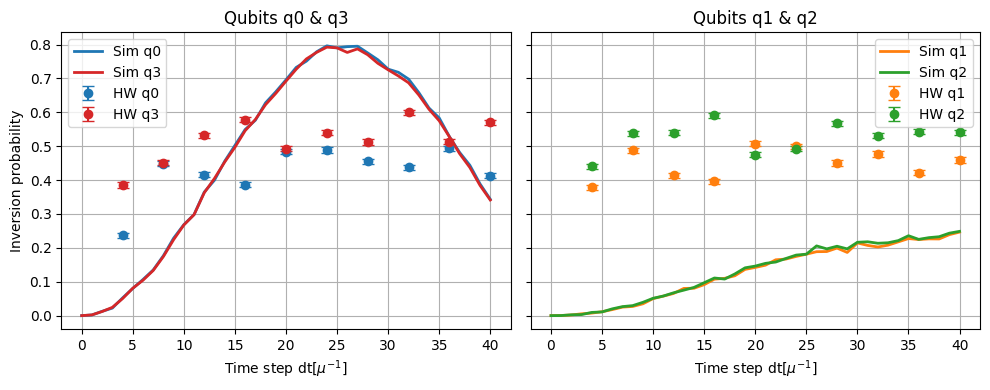

In [23]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

left_qubits  = [0, 3]
right_qubits = [1, 2]

# ===============================
# LEFT PANEL: q0, q3
# ===============================
ax = axes[0]

for q in left_qubits:

    color = f"C{q}"

    # --- Hardware ---
    y_hw = np.array(P_inv[q]).flatten()
    err_hw = np.sqrt(y_hw * (1 - y_hw) / shots)

    n_hw = min(len(times_hw), len(y_hw))   # safety

    ax.errorbar(
        times_hw[:n_hw],
        y_hw[:n_hw],
        yerr=err_hw[:n_hw],
        fmt='o',
        capsize=4,
        color=color,
        label=f"HW q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q]).flatten()

    n_sim = min(len(times_sim), len(y_sim))  # safety

    ax.plot(
        times_sim[:n_sim],
        y_sim[:n_sim],
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q0 & q3")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.set_ylabel("Inversion probability")
ax.grid(True)
ax.legend()


# ===============================
# RIGHT PANEL: q1, q2
# ===============================
ax = axes[1]

for q in right_qubits:

    color = f"C{q}"

    # --- Hardware ---
    y_hw = np.array(P_inv[q]).flatten()
    err_hw = np.sqrt(y_hw * (1 - y_hw) / shots)

    n_hw = min(len(times_hw), len(y_hw))

    ax.errorbar(
        times_hw[:n_hw],
        y_hw[:n_hw],
        yerr=err_hw[:n_hw],
        fmt='o',
        capsize=4,
        color=color,
        label=f"HW q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q]).flatten()

    n_sim = min(len(times_sim), len(y_sim))

    ax.plot(
        times_sim[:n_sim],
        y_sim[:n_sim],
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q1 & q2")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
from qiskit import QuantumCircuit, transpile

# --- Build logical circuit (2 qubits example) ---
qc = QuantumCircuit(2, 2)

qc.x(1)

# Hardware-friendly interaction (or original if only 2 qubits)
add_interaction_evolution_hw(qc, n=1, J=J, N=2)

# Draw logical circuit (before mapping)
qc.draw('mpl')
qc_dec=qc.decompose()
#qc_dec.draw(output="latex_source", filename="circuit.tex")

print(qc_dec.draw(output="text"))

        ┌───┐                                    ┌───┐┌──────┐     »
q_0: ───┤ H ├───────────■─────────────────────■──┤ H ├┤ √Xdg ├──■──»
     ┌──┴───┴───┐┌───┐┌─┴─┐┌───────────────┐┌─┴─┐├───┤├──────┤┌─┴─┐»
q_1: ┤ U(π,0,π) ├┤ H ├┤ X ├┤ Rz(0.0056401) ├┤ X ├┤ H ├┤ √Xdg ├┤ X ├»
     └──────────┘└───┘└───┘└───────────────┘└───┘└───┘└──────┘└───┘»
c: 2/══════════════════════════════════════════════════════════════»
                                                                   »
«                           ┌────┐                           
«q_0: ───────────────────■──┤ √X ├──■─────────────────────■──
«     ┌───────────────┐┌─┴─┐├────┤┌─┴─┐┌───────────────┐┌─┴─┐
«q_1: ┤ Rz(0.0056401) ├┤ X ├┤ √X ├┤ X ├┤ Rz(0.0056401) ├┤ X ├
«     └───────────────┘└───┘└────┘└───┘└───────────────┘└───┘
«c: 2/═══════════════════════════════════════════════════════
«                                                            


In [18]:
# Map to hardware topology
tqc = transpile(
    qc,
    backend,
    optimization_level=1
)
print(tqc.draw(output="text"))
tqc.draw(output="latex_source", filename="hardware_circuit.tex")

global phase: 5π/4
         ┌─────────┐┌────┐┌─────────┐                                        »
q_0 -> 0 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■──────────────────────────────────────»
         └──┬───┬──┘└────┘└─────────┘ │ ┌─────────┐┌────┐┌────────────┐┌────┐»
q_1 -> 1 ───┤ X ├─────────────────────■─┤ Rz(π/2) ├┤ √X ├┤ Rz(-3.136) ├┤ √X ├»
            └───┘                       └─────────┘└────┘└────────────┘└────┘»
«                          ┌────┐  ┌─────────┐                    »
«q_0 -> 0 ────────────■────┤ √X ├──┤ Rz(π/2) ├─■──────────────────»
«         ┌─────────┐ │ ┌──┴────┴─┐└──┬────┬─┘ │ ┌─────────┐┌────┐»
«q_1 -> 1 ┤ Rz(π/2) ├─■─┤ Rz(π/2) ├───┤ √X ├───■─┤ Rz(π/2) ├┤ √X ├»
«         └─────────┘   └─────────┘   └────┘     └─────────┘└────┘»
«                                              ┌────┐                      »
«q_0 -> 0 ────────────────────────────────■────┤ √X ├───■──────────────────»
«         ┌────────────┐┌────┐┌─────────┐ │ ┌──┴────┴─┐ │ ┌─────────┐┌────┐»
«q_1 -> 1 ┤ Rz(

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{{$\\mathrm{global\\,phase:\\,} \\mathrm{\\frac{5\\pi}{4}}$}\n\\Qcircuit @C=1.0em @R=0.2em @!R { \\\\\n\t \t\\nghost{{q}_{0}\\;\\mapsto\\;{0} :  } & \\lstick{{q}_{0}\\;\\mapsto\\;{0} :  } & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\gate{\\mathrm{\\sqrt{X}}} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{1} & \\gate{\\mathrm{\\sqrt{X}}} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{1} & \\gate{\\mathrm{\\sqrt{X}}} & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{1} & \\qw & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1}\\;\\mapsto\\;{1} :  } & \\lstick{{q}_{1}\\;\\mapsto\\;{1} :  } & \\gate{\\mathrm{X}} & \\qw & \\qw & \\control\\qw & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\gate{\\m

In [27]:
## Run with M3 error mitigation
import mthree

initial_bits = [0, 0, 1, 1]
# Interaction matrix
J = interaction_matrix(N, dm2, E)

# Initial state prepared outside
qc0 = QuantumCircuit(N, N)
qc0.x(2)# example: qubit 2 is nu_mu
qc0.x(3)# example: qubit 3 is nu_mu
P_inv = [[] for _ in range(N)]
P_inv_error = [[] for _ in range(N)]
dt=0.5
T_max = 40 
steps = int(T_max / (8*dt)) 
times_hw = np.linspace(4, T_max, steps)
shots = 4096

# ===============================
# M3 CALIBRATION
# ===============================
mit = mthree.M3Mitigation(backend)
mit.cals_from_system(range(N))

circuits = []

# ---------- Build circuits ----------
for t in times_hw:
    n=int(round(t / dt))
    qc = qc0.copy()

    add_interaction_evolution_hw(qc, n=n, J=J, N=N, dt=dt)

    qc.measure(range(N), range(N))

    tqc = transpile(
        qc,
        backend,
        optimization_level=1,
        scheduling_method="alap"
    )

    circuits.append(tqc)

# ---------- Run job ----------
job = sampler.run(circuits, shots=shots)

print("Job ID:", job.job_id())

result = job.result()

# ---------- Process results with M3 ----------
for idx, t in enumerate(times_hw):

    raw_counts = result[idx].data.c.get_counts()

    # ⭐ Apply measurement mitigation
    mitigated_probs = mit.apply_correction(raw_counts, range(N))

    p_inv_t = [0.0] * N

    # Note: M3 returns probabilities, not counts
    for bitstring, prob in mitigated_probs.items():

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    #times.append(n)

    for q in range(N):
        P_inv_error[q].append(p_inv_t[q])

    print(
        f"t = {t:2f} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f}, "
        f"q2_inv = {p_inv_t[2]:.4f}, "
        f"q3_inv = {p_inv_t[3]:.4f}"
    )

Job ID: d76gaa7q1anc738diqdg
t = 4.000000 | q0_inv = 0.2989, q1_inv = 0.2885, q2_inv = 0.3495, q3_inv = 0.6039
t = 8.000000 | q0_inv = 0.3143, q1_inv = 0.3969, q2_inv = 0.4800, q3_inv = 0.4502
t = 12.000000 | q0_inv = 0.3365, q1_inv = 0.4365, q2_inv = 0.5470, q3_inv = 0.5731
t = 16.000000 | q0_inv = 0.3421, q1_inv = 0.4411, q2_inv = 0.5485, q3_inv = 0.5688
t = 20.000000 | q0_inv = 0.3527, q1_inv = 0.4294, q2_inv = 0.5574, q3_inv = 0.5797
t = 24.000000 | q0_inv = 0.3426, q1_inv = 0.4324, q2_inv = 0.5566, q3_inv = 0.6116
t = 28.000000 | q0_inv = 0.3479, q1_inv = 0.4391, q2_inv = 0.5448, q3_inv = 0.6077
t = 32.000000 | q0_inv = 0.3603, q1_inv = 0.4342, q2_inv = 0.5480, q3_inv = 0.5941
t = 36.000000 | q0_inv = 0.3673, q1_inv = 0.4501, q2_inv = 0.5503, q3_inv = 0.5936
t = 40.000000 | q0_inv = 0.3630, q1_inv = 0.4309, q2_inv = 0.5415, q3_inv = 0.6088


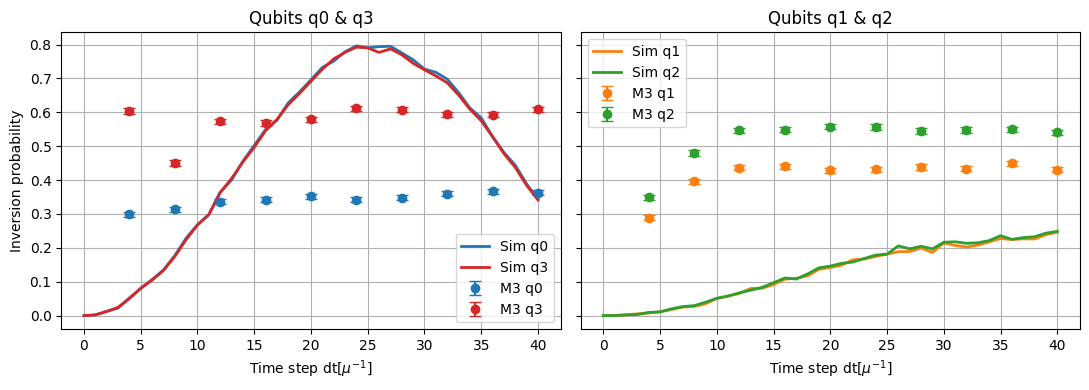

In [30]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

left_qubits  = [0, 3]
right_qubits = [1, 2]

# ===============================
# LEFT PANEL: q0, q3
# ===============================
ax = axes[0]

for q in left_qubits:

    color = f"C{q}"

    # --- M3 Mitigated ---
    y_m3 = np.array(P_inv_error[q]).flatten()
    n_m3 = min(len(times_hw), len(y_m3))

    # ⚠️ approximate error (since M3 gives quasi-probabilities)
    err_m3 = np.sqrt(np.abs(y_m3 * (1 - y_m3)) / shots)

    ax.errorbar(
        times_hw[:n_m3],
        y_m3[:n_m3],
        yerr=err_m3[:n_m3],
        fmt='o',
        capsize=4,
        color=color,
        label=f"M3 q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q]).flatten()
    n_sim = min(len(times_sim), len(y_sim))

    ax.plot(
        times_sim[:n_sim],
        y_sim[:n_sim],
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q0 & q3")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.set_ylabel("Inversion probability")
ax.grid(True)
ax.legend()


# ===============================
# RIGHT PANEL: q1, q2
# ===============================
ax = axes[1]

for q in right_qubits:

    color = f"C{q}"

    # --- M3 Mitigated ---
    y_m3 = np.array(P_inv_error[q]).flatten()
    n_m3 = min(len(times_hw), len(y_m3))

    err_m3 = np.sqrt(np.abs(y_m3 * (1 - y_m3)) / shots)

    ax.errorbar(
        times_hw[:n_m3],
        y_m3[:n_m3],
        yerr=err_m3[:n_m3],
        fmt='o',
        capsize=4,
        color=color,
        label=f"M3 q{q}"
    )

    # --- Simulation ---
    y_sim = np.array(P_inv_sim[q]).flatten()
    n_sim = min(len(times_sim), len(y_sim))

    ax.plot(
        times_sim[:n_sim],
        y_sim[:n_sim],
        '-',
        linewidth=2,
        color=color,
        label=f"Sim q{q}"
    )

ax.set_title("Qubits q1 & q2")
ax.set_xlabel(r"Time step dt[$\mu^{-1}$]")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()